
## Notebook for making first few figures in "Impacts of Near-Inertial Currents on Surface Waves in Idealized Simulations


In [2]:
from scipy.io import loadmat, savemat
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import sys
import os
import haversine
import xarray as xr
from haversine import haversine, Unit
from src.find_phase_inds import find_phase_inds
import matplotlib.gridspec as gridspec
from pathlib import Path

# 1. Get the path of the parent directory (my_project)
parent_dir = str(Path().resolve().parent)
# 2. Append it to sys.path if it isn't already there
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

# 3. Import find_phase_inds
from src.find_phase_inds import find_phase_inds


import cmocean
ww3_data_control = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/BC_10/100_288/no_cur.nc")
xkm = np.linspace(-haversine((0, -150), (0, -140), unit=Unit.KILOMETERS)/2, haversine((0, -150), (0, -140), unit=Unit.KILOMETERS)/2, len(ww3_data_control.longitude))
ykm = np.linspace(-haversine((-5, -145), (5, -145), unit=Unit.KILOMETERS)/2, haversine((-5, -145), (5, -145), unit=Unit.KILOMETERS)/2, len(ww3_data_control.latitude))



### Two row Hs vs. Inertial phase figure

In [47]:
#load wave data
sigma = 100
# ww3_data_control = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/results/control_run_w_tb_forcing_bothyes.nc")
# ww3_data_100 = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/results/100km_bothyes.nc")
# steady_east = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/results/100km_bothyes_steady_east.nc")
# steady_south =  xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/results/100km_bothyes_steady_south.nc")
# steady_west = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/results/100km_bothyes_steady_west.nc")
# steady_north =  xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/results/100km_bothyes_steady_north.nc")
ww3_data_control_s1 = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/BC_10/100_288/no_cur.nc")

ww3_data_100_s1_f12 = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/BC_10/100_12/all_cur.nc")
ww3_data_100_s1_f24 = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/BC_10/100_24/all_cur.nc")
ww3_data_100_s1_f48 = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/BC_10/100_48/all_cur.nc")
ww3_data_100_s1_f96 = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/BC_10/100_96/all_cur.nc")
ww3_data_100_s1_f288 = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/BC_10/100_288/all_cur.nc")
ww3_data_100_s1_steadyE = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/BC_10/100_steady_east/all_cur.nc")
ww3_data_100_s1_steadyS = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/BC_10/100_steady_south/all_cur.nc")
ww3_data_100_s1_steadyW = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/BC_10/100_steady_west/all_cur.nc")
ww3_data_100_s1_steadyN = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/BC_10/100_steady_north/all_cur.nc")


#ww3_data_control_s45 = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/hyak_outputs/s_45_outputs/BC_10/100_288/no_cur.nc")
#ww3_data_100_s45 = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/hyak_outputs/s_45_outputs/BC_10/100_24/all_cur.nc")



#steady_east = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/BC_10/100_steady_east/all_cur.nc")
#steady_south =  xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/BC_10/100_steady_south/all_cur.nc")
#steady_west = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/BC_10/100_steady_west/all_cur.nc")
#steady_north =  xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/BC_10/100_steady_north/all_cur.nc")

hs_anomaly_24 = 100*(ww3_data_100_s1_f24.hs-ww3_data_control.hs)/ww3_data_control.hs
hs_anomaly_96 = 100*(ww3_data_100_s1_f96.hs-ww3_data_control.hs)/ww3_data_control.hs

#mss_anomaly = 100*(ww3_data_100.mssu-ww3_data_control.mssu)/ww3_data_control.mssu

#Indecies for different phases (these were found manually)
#inds = [746, 767, 789, 810]
indsw = find_phase_inds(ww3_data_100_s1_f24, "west", 0.2)[-2]
indse = find_phase_inds(ww3_data_100_s1_f24, "east", 0.2)[-2]
indsn = find_phase_inds(ww3_data_100_s1_f24, "north", 0.2)[-1]
indss = find_phase_inds(ww3_data_100_s1_f24, "south", 0.2)[-2]
inds_24 = np.array([indsw, indsn, indse, indss])

indsw = find_phase_inds(ww3_data_100_s1_f96, "west", 0.2)[-2]
indse = find_phase_inds(ww3_data_100_s1_f96, "east", 0.2)[-2]
indsn = find_phase_inds(ww3_data_100_s1_f96, "north", 0.2)[-1]
indss = find_phase_inds(ww3_data_100_s1_f96, "south", 0.2)[-2]
inds_96 = np.array([indsw, indsn, indse, indss])


xkm = np.linspace(-haversine((0, -150), (0, -140), unit=Unit.KILOMETERS)/2, haversine((0, -150), (0, -140), unit=Unit.KILOMETERS)/2, len(ww3_data_control.longitude))
ykm = np.linspace(-haversine((-5, -145), (5, -145), unit=Unit.KILOMETERS)/2, haversine((-5, -145), (5, -140), unit=Unit.KILOMETERS)/2, len(ww3_data_control.latitude))
test=np.linspace(-10, 10, len(xkm)*len(ykm))

fig, ax = plt.subplots(4, 4, figsize=(25, 8))

fake_cbar = ax[0,0].contourf(xkm, ykm, test.reshape((len(xkm), len(ykm))), vmin=-5, vmax=5, levels=20, cmap='bwr')

for indf in range(4):
    for ind in range(4):
        #hs_anom = 
        cm = ax[indf, ind].contourf(xkm, ykm, hs_anomaly_24[inds_24[ind], :, :], vmin=-5, vmax=5, levels=20, cmap='bwr')
        #ax[0, ind].quiver(ww3_data_control.longitude[::4]-360, ww3_data_control.latitude[::4], ww3_data_100.ucur[inds[ind], ::4, ::4], ww3_data_100.vcur[inds[ind], ::4, ::4])
        ax[indf, ind].quiver(xkm[40], ykm[40], ww3_data_100_s1_f24.ucur[inds_24[ind], 40, 40], ww3_data_100_s1_f24.vcur[inds_24[ind], 40, 40], scale=1.5)
        cs = ax[indf, ind].contour(xkm, ykm, np.sqrt(ww3_data_100_s1_f24.ucur[inds_24[ind], :, :]**2+ww3_data_100_s1_f24.vcur[inds_24[ind], :, :]**2), linestyles='dashed', colors='k', levels=[0.05, 0.1, 0.15, 0.2])
        ax[indf, ind].clabel(cs, fontsize=10)
        ax[indf,ind].set_xlim(-550, 550)
        ax[indf,ind].set_ylim(-550, 550)
        
        #steady_anomaly = 100*(steady_list[ind].hs-ww3_data_control.hs)/ww3_data_control.hs
        #steady_anomaly = 100*(steady_list[ind].mssu-ww3_data_control.mssu)/ww3_data_control.mssu
        cm2 = ax[1, ind].contourf(xkm, ykm, hs_anomaly_96[inds_96[ind], :, :], vmin=-5, vmax=5, levels=20, cmap='bl')
        ax[1, ind].quiver(xkm[40], ykm[40], ww3_data_100_s1_f96.ucur[inds_96[ind], 40, 40], ww3_data_100_s1_f96.vcur[inds_96[ind], 40, 40], scale=1.5)
        cs = ax[1, ind].contour(xkm, ykm, np.sqrt(ww3_data_100_s1_f96.ucur[inds_96[ind], :, :]**2+ww3_data_100_s1_f96.vcur[inds_96[ind], :, :]**2), linestyles='dashed', colors='k', levels=[0.05, 0.1, 0.15, 0.2])
        ax[1, ind].clabel(cs, fontsize=10)
        ax[1,ind].set_xlim(-550, 550)
        ax[1,ind].set_ylim(-550, 550)
#ax[1, -1].legend()
#ax[0,0].set_title(r"$\phi=0$", fontsize=18)
ax[0,0].set_title(r"West", fontsize=18, pad=15)

#ax[0,1].set_title(r"$\phi=\pi/2$", fontsize=18)
ax[0,1].set_title(r"North", fontsize=18, pad=15)

#ax[0,2].set_title(r"$\phi=\pi$", fontsize=18)
ax[0,2].set_title(r"East", fontsize=18, pad=15)

#ax[0,3].set_title(r"$\phi=3\pi/2$", fontsize=18)
ax[0,3].set_title(r"South", fontsize=18, pad=15)

ax[0,0].set_ylabel("Inertial Currents", fontsize=18, labelpad=15)
ax[1, 0].set_ylabel("Steady Currents", fontsize=18, labelpad=15)
fig.subplots_adjust(right=0.8)

#cbar = fig.colorbar(cm, ax=ax.ravel().tolist())
#cbar.set_label(r"$\Delta$ Hs (%)")
cbar= fig.colorbar(fake_cbar, ax=ax)
cbar.set_label(r"$\Delta$ Hs (%)", fontsize=18)
cbar.ax.set_ylim(-8, 8)

ax[0,0].set_ylabel("$T_{i}$ = 24 hrs", fontsize=16)
ax[1,0].set_ylabel("$T_{i}$ = 96 hrs", fontsize=16)

ax[1,0].set_xlabel("km", fontsize=16,labelpad=15)
ax[1,1].set_xlabel("km", fontsize=16,labelpad=15)
ax[1,2].set_xlabel("km", fontsize=16,labelpad=15)
ax[1,3].set_xlabel("km", fontsize=16,labelpad=15)


plt.savefig("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/figures/comparing_f24_f96"+str(sigma)+".png", dpi = 300, bbox_inches='tight')


SyntaxError: invalid syntax (2103887442.py, line 62)

#### Same but more inertial frequency rows

Text(0.5, 0, 'km')

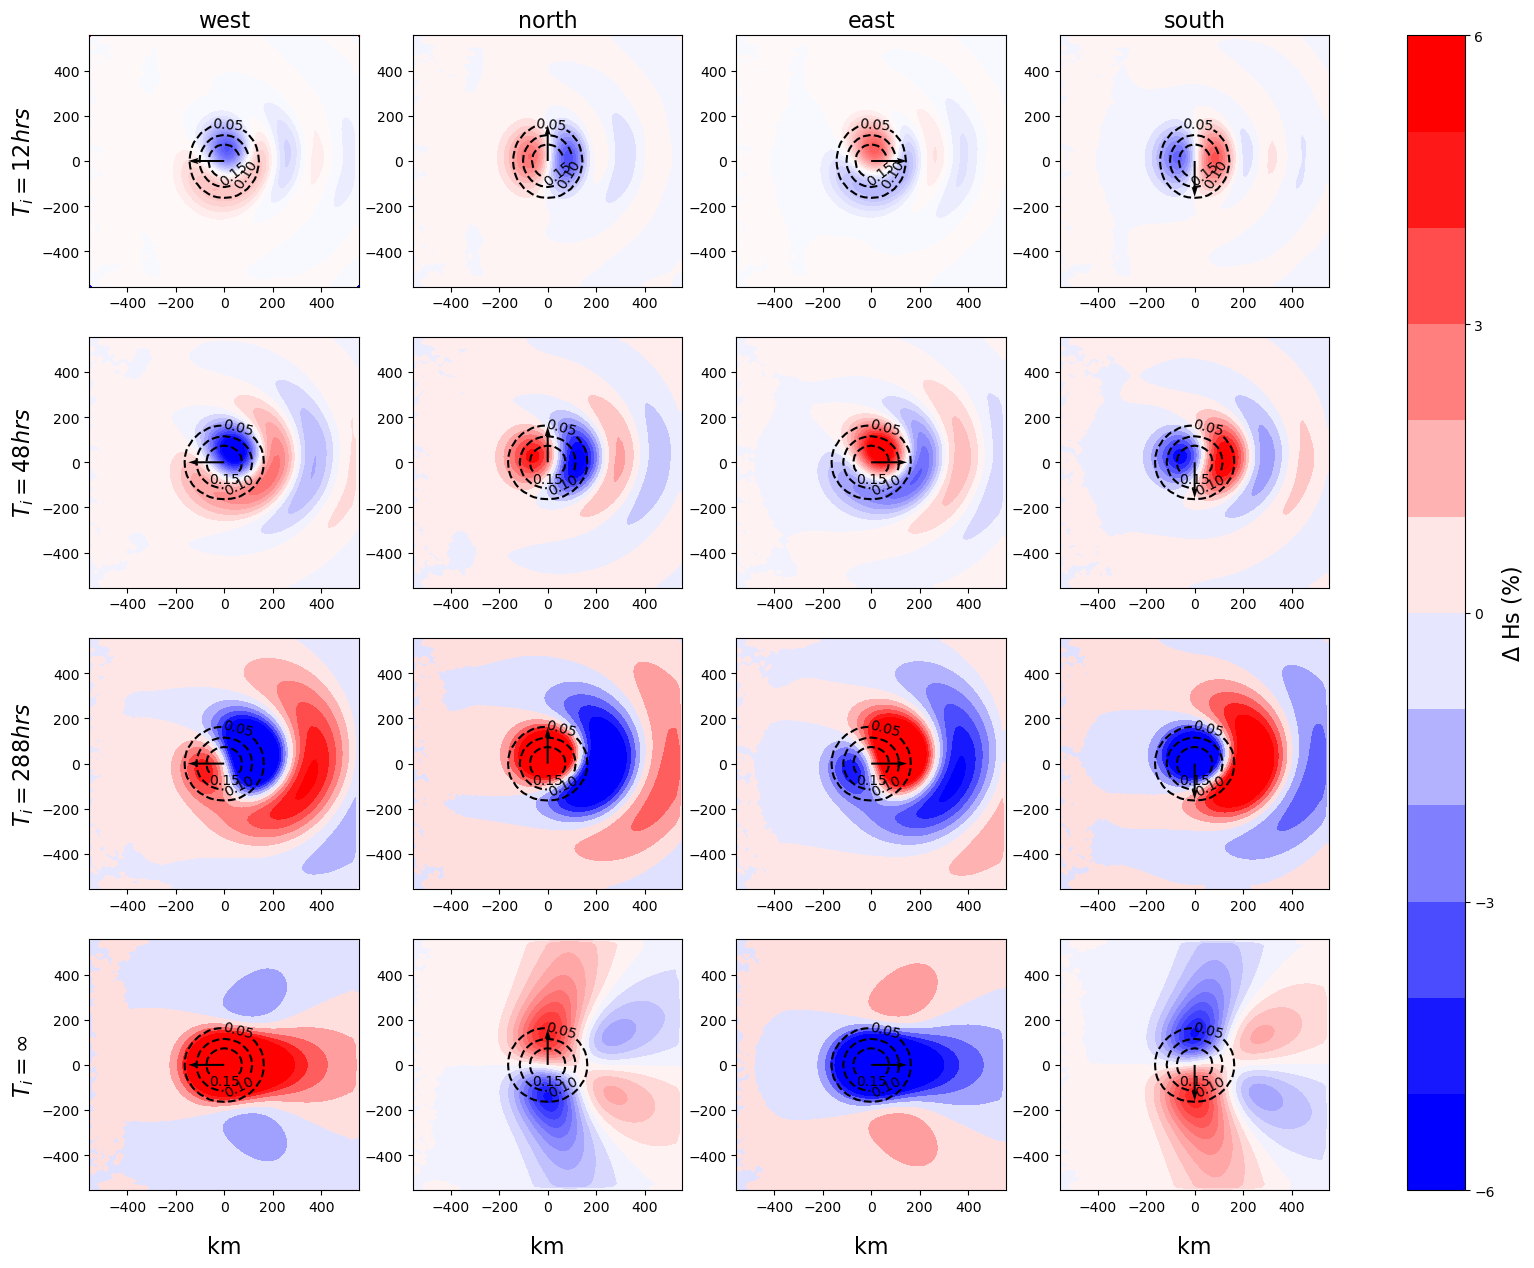

In [9]:
#Save path
spath = "/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/"
#params
folders = ["BC_5"] #Boundary Conditions (for different peak frequencies
#cur_files = ["100_12", "100_24", "100_36", "100_48", "100_96","100_288", "100_steady_west"] #Current Widths
cur_files = ["100_8", "100_12","100_24"]#, "100_steady_west"] #Current Widths
sigma = "100"
dirs = ["west", "north", "east", "south"] #Different physics parameters
#runs_labels = ["advection", "k-shift", "refraction", "total currents"]

#cur_labels=["$c_g/fL$=3", "$c_g/fL$=6", "$c_g/fL$=10", "$c_g/fL$=13", "$c_g/fL$=27", "$c_g/fL$=80", "$c_g/fL$=$\infty$"]
cur_labels = ['$T_{i}=12hrs$', '$T_{i}=48hrs$', '$T_{i}=288hrs$', '$T_{i}=\infty$']
fig, ax = plt.subplots(len(cur_files)+1, len(dirs), figsize=(20, 15)) # Make figure


xkm = np.linspace(-haversine((0, -150), (0, -140), unit=Unit.KILOMETERS)/2, haversine((0, -150), (0, -140), unit=Unit.KILOMETERS)/2, len(ww3_data_control.longitude))
ykm = np.linspace(-haversine((-5, -145), (5, -145), unit=Unit.KILOMETERS)/2, haversine((-5, -145), (5, -145), unit=Unit.KILOMETERS)/2, len(ww3_data_control.latitude))
test=np.linspace(-10, 10, len(xkm)*len(ykm))

#fig, ax = plt.subplots(4, 4, figsize=(25, 8))

fake_cbar = ax[0,0].contourf(xkm, ykm, test.reshape((len(xkm), len(ykm))), vmin=-5, vmax=5, levels=20, cmap='bwr')
bc = "BC_10"
for i in range(len(cur_files)):
    cur = cur_files[i]
    #Plot different currents as rows and phsyics runs as columns
    row_count = i
    col_count = 0
    data = xr.open_dataset(spath+bc+"/"+cur+"/all_cur.nc")
    control = xr.open_dataset(spath+bc+"/"+"100_576"+"/"+"no_cur"+".nc")
    anom = 100*(data.hs - control.hs)/control.hs

    #Get cur name
    cur = cur_files[i]
    ax[i, 0].set_ylabel(cur_labels[i], fontsize=16)
    for run_i in range(len(dirs)):
        inds = find_phase_inds(data, dirs[run_i], 0.2)
        cm = ax[i, run_i].contourf(xkm, ykm, anom[inds[-1], :, :], levels=20, vmin=-1, vmax=1, cmap='bwr')

       # ax[i, run_i].quiver(xkm, ykm, data.ucur[inds[-1], ::4, ::4], data.vcur[inds[-1], ::4, ::4], scale=1.5)
        ax[i, run_i].quiver(xkm[40], ykm[40], data.ucur[inds[-1], 40, 40], data.vcur[inds[-1], 40, 40], scale=1.5)
        cs = ax[i, run_i].contour(xkm, ykm, np.sqrt(data.ucur[inds[-1], :, :]**2+data.vcur[inds[-1], :, :]**2), linestyles='dashed', colors='k', levels=[0.05, 0.1, 0.15, 0.2])
        ax[i, run_i].clabel(cs, fontsize=10)

        if i==0:
            ax[i, col_count].set_title(dirs[run_i], fontsize=16)
        col_count+=1
        #plt.colorbar(cm)

for run_i in range(len(dirs)):
    #inds = find_phase_inds(data, dirs[run_i], 0.2)
    dir = dirs[run_i]
    data = xr.open_dataset(spath+bc+"/100_steady_"+dir+"/all_cur.nc")
    anom = 100*(data.hs - control.hs)/control.hs
    cm = ax[3, run_i].contourf(xkm, ykm, anom[700, :, :], levels=20, vmin=-1, vmax=1, cmap='bwr')

    ax[3, run_i].quiver(xkm[40], ykm[40], data.ucur[700, 40, 40], data.vcur[700, 40, 40], scale=1.5)
    cs = ax[3, run_i].contour(xkm, ykm, np.sqrt(data.ucur[700, :, :]**2+data.vcur[700, :, :]**2), linestyles='dashed', colors='k', levels=[0.05, 0.1, 0.15, 0.2])
    ax[3, run_i].clabel(cs, fontsize=10)

    if i==0:
        ax[3, run_i].set_title(dirs[run_i], fontsize=16)
    #plt.colorbar(cm)
ax[3, 0].set_ylabel("$T_{i}=\infty$", fontsize=16)
cbar= fig.colorbar(fake_cbar, ax=ax)
cbar.ax.set_ylim(-6,6)
cbar.ax.set_ylabel(r"$\Delta$ Hs (%)", fontsize=16)


ax[3,0].set_xlabel("km", fontsize=16,labelpad=15)
ax[3,1].set_xlabel("km", fontsize=16,labelpad=15)
ax[3,2].set_xlabel("km", fontsize=16,labelpad=15)
ax[3,3].set_xlabel("km", fontsize=16,labelpad=15)

#plt.savefig("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/figures/comparing_fs"+str(sigma)+".png", dpi = 300, bbox_inches='tight')



FileNotFoundError: [Errno 2] No such file or directory: b'/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/hyak_output/BCs_s45/outputs/BC_10/100_4/all_cur_full.nc'

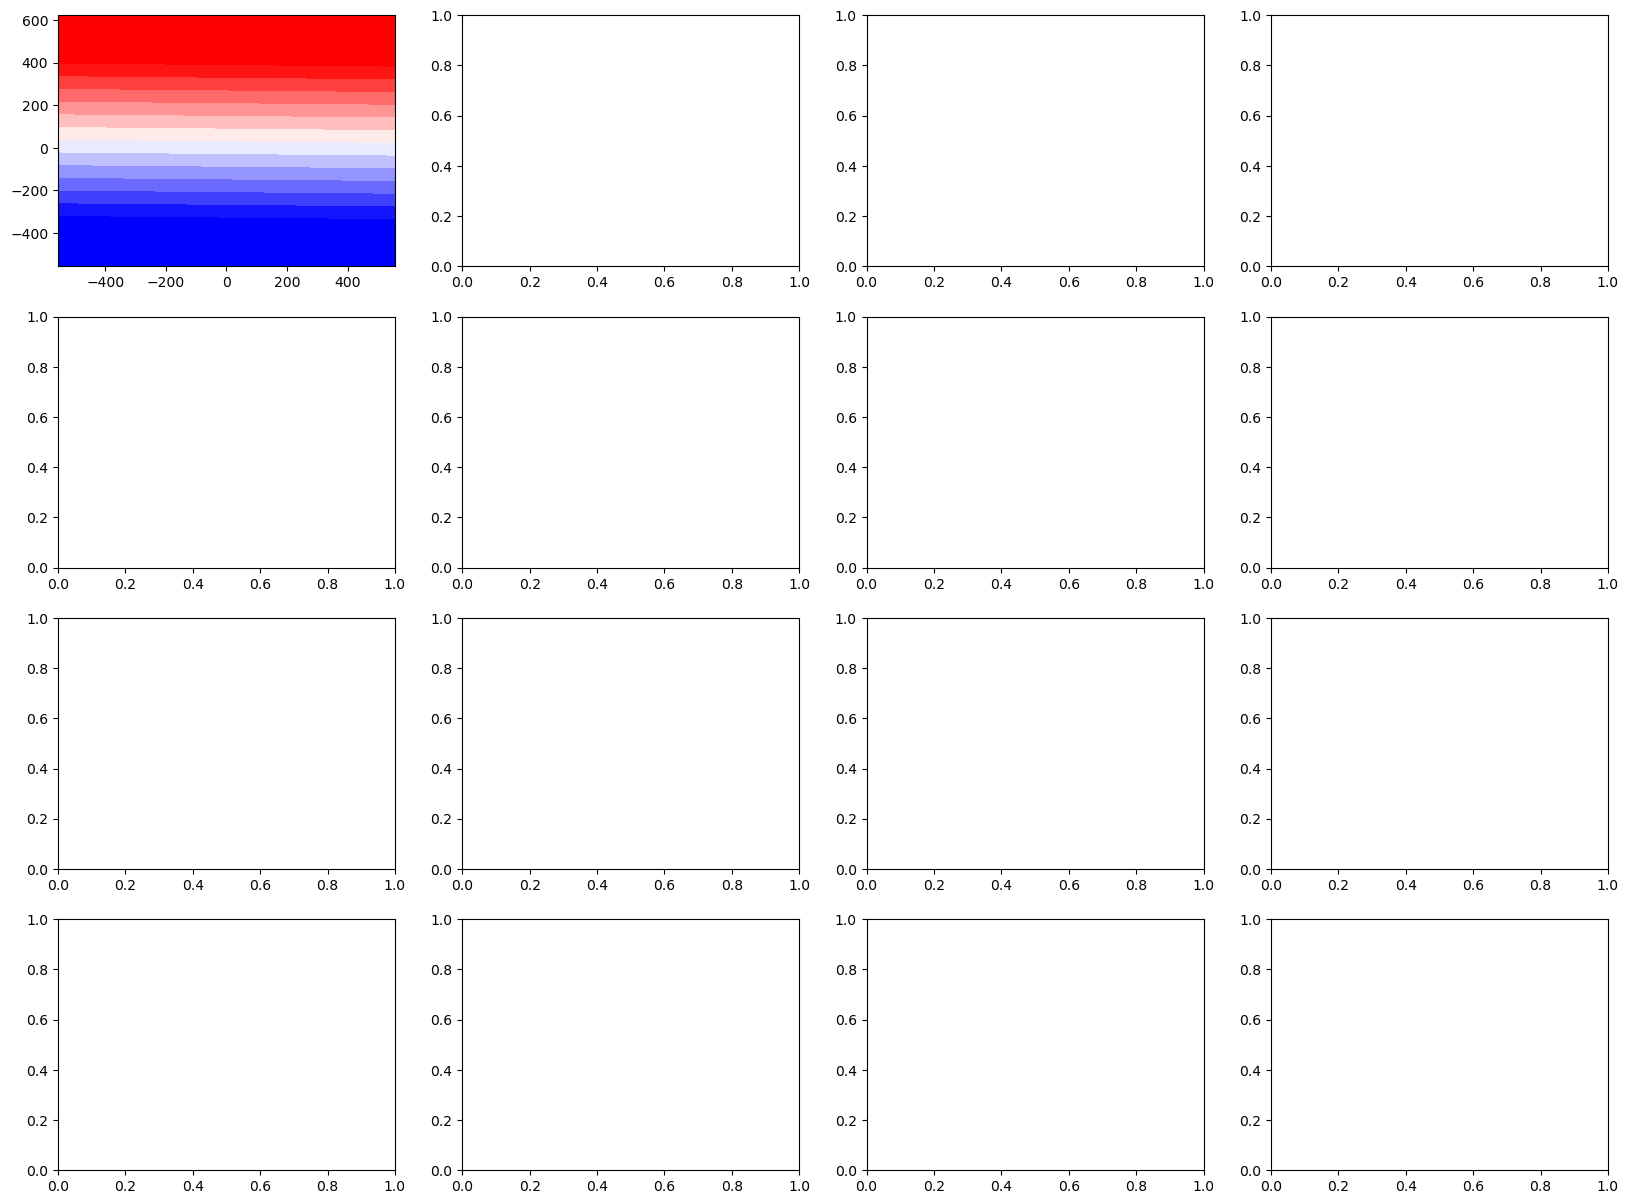

In [38]:
""" 
Do the same but s_45
"""

#Save path
spath = "/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/hyak_output/BCs_s45/outputs/"
#params
folders = ["BC_5"] #Boundary Conditions (for different peak frequencies
#cur_files = ["100_12", "100_24", "100_36", "100_48", "100_96","100_288", "100_steady_west"] #Current Widths
cur_files = ["100_12", "100_24","100_36"]#, "100_steady_west"] #Current Widths

dirs = ["west", "north", "east", "south"] #Different physics parameters
#runs_labels = ["advection", "k-shift", "refraction", "total currents"]

#cur_labels=["$c_g/fL$=3", "$c_g/fL$=6", "$c_g/fL$=10", "$c_g/fL$=13", "$c_g/fL$=27", "$c_g/fL$=80", "$c_g/fL$=$\infty$"]
cur_labels = ['$T_{i}=12hrs$', '$T_{i}=48hrs$', '$T_{i}=288hrs$']
fig, ax = plt.subplots(len(cur_files)+1, len(dirs), figsize=(20, 15)) # Make figure

ww3_data_control= xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/BC_10/100_288/no_cur.nc")
xkm = np.linspace(-haversine((0, -150), (0, -140), unit=Unit.KILOMETERS)/2, haversine((0, -150), (0, -140), unit=Unit.KILOMETERS)/2, len(ww3_data_control.longitude))
ykm = np.linspace(-haversine((-5, -145), (5, -145), unit=Unit.KILOMETERS)/2, haversine((-5, -145), (5, -140), unit=Unit.KILOMETERS)/2, len(ww3_data_control.latitude))
test=np.linspace(-10, 10, len(xkm)*len(ykm))

#fig, ax = plt.subplots(4, 4, figsize=(25, 8))

fake_cbar = ax[0,0].contourf(xkm, ykm, test.reshape((len(xkm), len(ykm))), vmin=-6, vmax=6, levels=20, cmap='bwr')
bc = "BC_10"
for i in range(len(cur_files)):
    cur = cur_files[i]
    #Plot different currents as rows and phsyics runs as columns
    row_count = i
    col_count = 0
    data = xr.open_dataset(spath+bc+"/"+cur+"/all_cur_full.nc")
    control = xr.open_dataset(spath+bc+"/"+"100_288"+"/"+"no_cur_full"+".nc")
    anom = 100*(data.hs - control.hs)/control.hs

    #Get cur name
    cur = cur_files[i]
    ax[i, 0].set_ylabel(cur_labels[i], fontsize=16)
    for run_i in range(len(dirs)):
        inds = find_phase_inds(data, dirs[run_i], 0.2)
        cm = ax[i, run_i].contourf(xkm, ykm, anom[inds[-2], :, :], levels=20, vmin=-6, vmax=6, cmap='bwr')

       # ax[i, run_i].quiver(xkm, ykm, data.ucur[inds[-1], ::4, ::4], data.vcur[inds[-1], ::4, ::4], scale=1.5)
        ax[i, run_i].quiver(xkm[40], ykm[40], data.ucur[inds[-1], 40, 40], data.vcur[inds[-1], 40, 40], scale=1.5)
        cs = ax[i, run_i].contour(xkm, ykm, np.sqrt(data.ucur[inds[-1], :, :]**2+data.vcur[inds[-1], :, :]**2), linestyles='dashed', colors='k', levels=[0.05, 0.1, 0.15, 0.2])
        ax[i, run_i].clabel(cs, fontsize=10)

        if i==0:
            ax[i, col_count].set_title(dirs[run_i], fontsize=16)
        col_count+=1
        #plt.colorbar(cm)

for run_i in range(len(dirs)):
    #inds = find_phase_inds(data, dirs[run_i], 0.2)
    dir = dirs[run_i]
    data = xr.open_dataset(spath+bc+"/100_steady_"+dir+"/all_cur_full.nc")
    anom = 100*(data.hs - control.hs)/control.hs
    cm = ax[3, run_i].contourf(xkm, ykm, anom[700, :, :], levels=20, vmin=-6, vmax=6, cmap='bwr')

    ax[3, run_i].quiver(xkm[40], ykm[40], data.ucur[700, 40, 40], data.vcur[700, 40, 40], scale=1.5)
    cs = ax[3, run_i].contour(xkm, ykm, np.sqrt(data.ucur[700, :, :]**2+data.vcur[700, :, :]**2), linestyles='dashed', colors='k', levels=[0.05, 0.1, 0.15, 0.2])
    ax[3, run_i].clabel(cs, fontsize=10)

    if i==0:
        ax[3, run_i].set_title(dirs[run_i], fontsize=16)
    #plt.colorbar(cm)
ax[3, 0].set_ylabel("$T_{i}=\infty$", fontsize=16)
cbar= fig.colorbar(fake_cbar, ax=ax)
cbar.ax.set_ylim(-6,6)
cbar.ax.set_ylabel(r"$\Delta$ Hs (%)", fontsize=16)


ax[3,0].set_xlabel("km", fontsize=16,labelpad=15)
ax[3,1].set_xlabel("km", fontsize=16,labelpad=15)
ax[3,2].set_xlabel("km", fontsize=16,labelpad=15)
ax[3,3].set_xlabel("km", fontsize=16,labelpad=15)

#plt.savefig("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/figures/comparing_fs"+str(sigma)+".png", dpi = 300, bbox_inches='tight')



## Does Reducing the model timesteps reduce the Garden Sprinkler effect for s=45?

Switch from 
cfl=600, xyT = 300, kthT=300 
to 
cfl=150, xyT = 75, kthT=75 


Text(0, 0.5, 'cfl=150s')

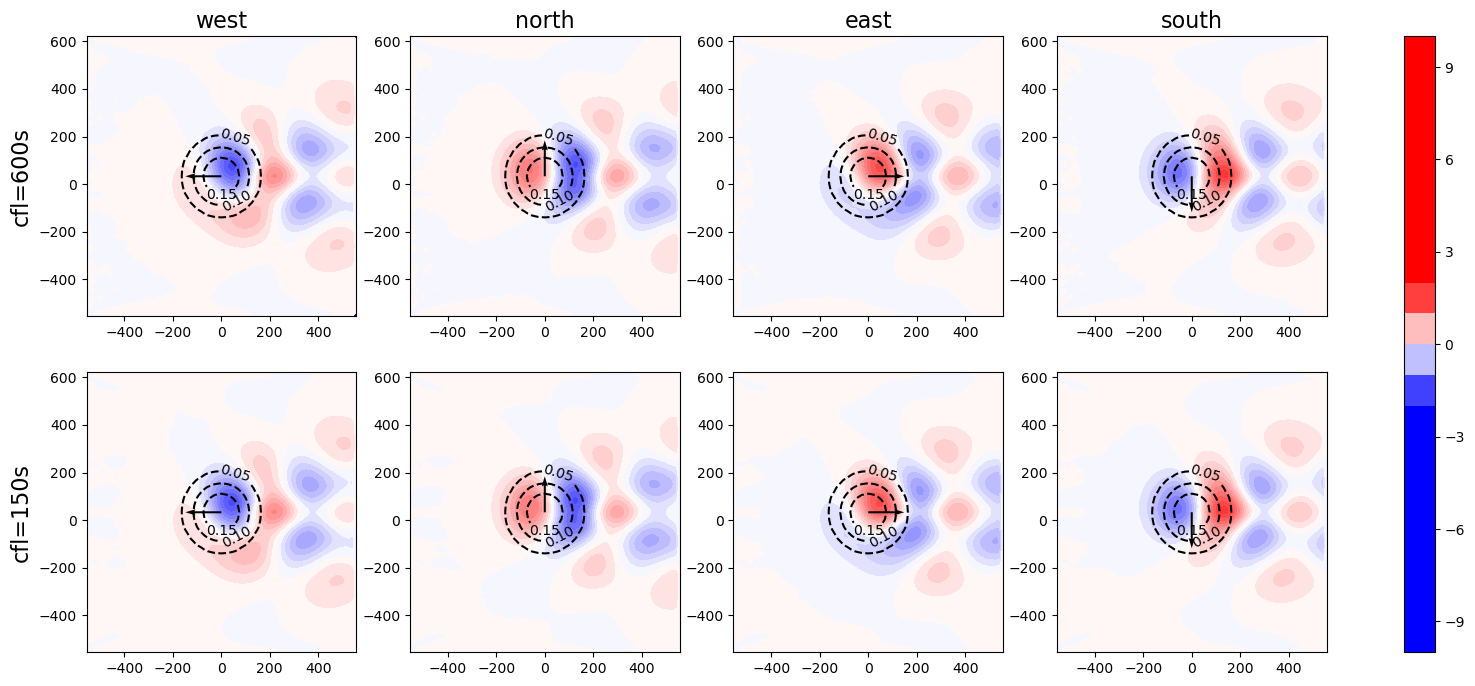

In [23]:

#Save path
spath = "/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/hyak_output/BCs_s45/outputs/"
#params
folders = ["BC_15"] #Boundary Conditions (for different peak frequencies
#cur_files = ["100_12", "100_24", "100_36", "100_48", "100_96","100_288", "100_steady_west"] #Current Widths
cur_files = ["100_12"]#, "100_24","100_36"]#, "100_steady_west"] #Current Widths

dirs = ["west", "north", "east", "south"] #Different physics parameters
#runs_labels = ["advection", "k-shift", "refraction", "total currents"]

#cur_labels=["$c_g/fL$=3", "$c_g/fL$=6", "$c_g/fL$=10", "$c_g/fL$=13", "$c_g/fL$=27", "$c_g/fL$=80", "$c_g/fL$=$\infty$"]
cur_labels = ['$T_{i}=12hrs$', '$T_{i}=48hrs$', '$T_{i}=288hrs$']
fig, ax = plt.subplots(2, len(dirs), figsize=(20, 8)) # Make figure

ww3_data_control= xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/BC_10/100_288/no_cur.nc")
xkm = np.linspace(-haversine((0, -150), (0, -140), unit=Unit.KILOMETERS)/2, haversine((0, -150), (0, -140), unit=Unit.KILOMETERS)/2, len(ww3_data_control.longitude))
ykm = np.linspace(-haversine((-5, -145), (5, -145), unit=Unit.KILOMETERS)/2, haversine((-5, -145), (5, -140), unit=Unit.KILOMETERS)/2, len(ww3_data_control.latitude))
test=np.linspace(-10, 10, len(xkm)*len(ykm))

#fig, ax = plt.subplots(4, 4, figsize=(25, 8))

fake_cbar = ax[0,0].contourf(xkm, ykm, test.reshape((len(xkm), len(ykm))), vmin=-2, vmax=2, levels=20, cmap='bwr')
bc = "BC_10"
for i in range(2):
    cur = cur_files[0]
    #Plot different currents as rows and phsyics runs as columns
    row_count = i
    col_count = 0
    if i==0:
        data = xr.open_dataset(spath+bc+"/"+cur+"/all_cur_full.nc")
    else:
        data = xr.open_dataset(spath+bc+"/"+cur+"/all_cur_full_shortTs.nc")

    control = xr.open_dataset(spath+bc+"/"+"100_288"+"/"+"no_cur_full"+".nc")
    anom = 100*(data.hs - control.hs)/control.hs

    #Get cur name
    cur = cur_files[0]
    for run_i in range(len(dirs)):
        inds = find_phase_inds(data, dirs[run_i], 0.2)
        #print(inds)
        cm = ax[i, run_i].contourf(xkm, ykm, anom[inds[-10], :, :], levels=20, vmin=-2, vmax=2, cmap='bwr')

       # ax[i, run_i].quiver(xkm, ykm, data.ucur[inds[-1], ::4, ::4], data.vcur[inds[-1], ::4, ::4], scale=1.5)
        ax[i, run_i].quiver(xkm[40], ykm[40], data.ucur[inds[-1], 40, 40], data.vcur[inds[-1], 40, 40], scale=1.5)
        cs = ax[i, run_i].contour(xkm, ykm, np.sqrt(data.ucur[inds[-1], :, :]**2+data.vcur[inds[-1], :, :]**2), linestyles='dashed', colors='k', levels=[0.05, 0.1, 0.15, 0.2])
        ax[i, run_i].clabel(cs, fontsize=10)

        if i==0:
            ax[i, col_count].set_title(dirs[run_i], fontsize=16)
        col_count+=1
        #plt.colorbar(cm)
cbar= fig.colorbar(fake_cbar, ax=ax)
ax[0, 0].set_ylabel("cfl=600s", fontsize=16)
ax[1, 0].set_ylabel("cfl=150s", fontsize=16)



# Plot x-axis slice of sample Ti and Steady runs

<Figure size 640x480 with 0 Axes>

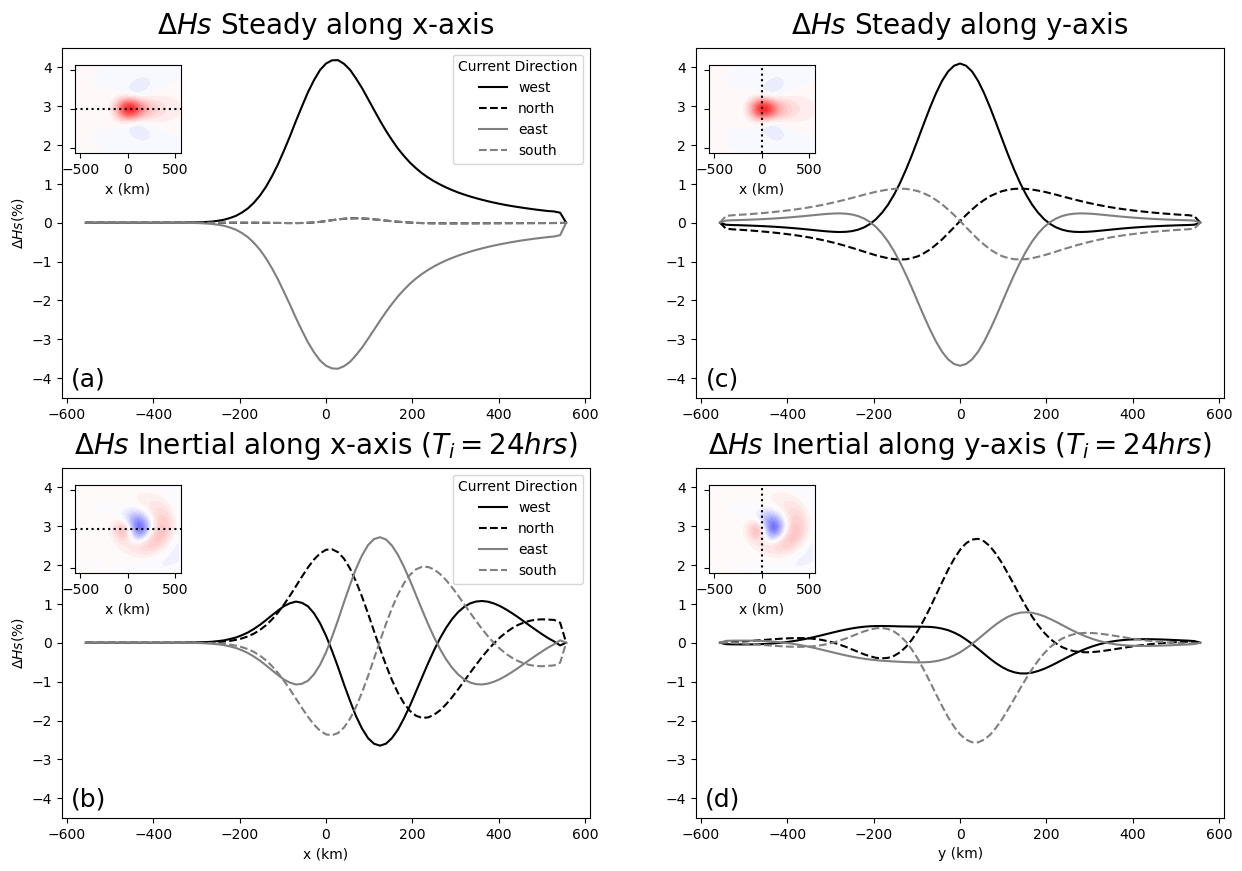

In [60]:
"""
Ok plot based on phase of current
"""
#Load desired data
spath="/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/BC_10/"
data = xr.open_dataset(spath+"100_24/all_cur.nc")
ww3_data_control = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/BC_10/100_288/no_cur.nc")

#Calculate Anomaly
hs_anomaly = 100*(data.hs-ww3_data_control.hs)/ww3_data_control.hs
plt.figure()
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

dirs = ['west', 'north', 'east', 'south']
lines = ['-', '--', '-', '--']
colors = ['k', 'k', 'tab:gray', 'tab:gray']
for i in range(len(dirs)):
    dir = dirs[i]
    line = lines[i]
    color=colors[i]
    inds = find_phase_inds(data, dir, 0.2)
    data_steady = xr.open_dataset(spath+"/100_steady_"+dir+"/all_cur.nc")
    anom_steady = 100*(data_steady.hs - control.hs)/control.hs


    ax[1, 0].plot(xkm, hs_anomaly[inds[-1], 40, :], line, label=dir, c=color)
    ax[0, 0].plot(xkm, anom_steady[inds[-1], 40, :], line, label=dir, c=color)

    ax[0, 1].plot(ykm, anom_steady[inds[-1], :, 40], line, label=dir, c=color)
    ax[1, 1].plot(ykm, hs_anomaly[inds[-1], :, 40], line, label=dir, c=color)


ax[1, 0].set_xlabel("x (km)")
ax[1, 0].set_ylabel("$\Delta Hs $(%)")

ax[1, 0].set_ylim([-4.5, 4.5])
ax[1, 0].legend(title='Current Direction')
ax[1, 0].set_title("$\Delta Hs$ Inertial along x-axis ($T_{i}=24hrs$)", fontsize=20, pad=10)

ax[0, 0].legend(title='Current Direction')
ax[0, 0].set_ylim([-4.5, 4.5])
ax[0, 0].set_ylabel("$\Delta Hs $(%)")
ax[0, 0].set_title("$\Delta Hs$ Steady along x-axis", fontsize=20, pad=10)

ax[0, 1].set_title("$\Delta Hs$ Steady along y-axis", fontsize=20, pad=10)
ax[1, 1].set_title("$\Delta Hs$ Inertial along y-axis ($T_{i}=24hrs$)", fontsize=20, pad=10)

ax[1, 1].set_xlabel("y (km)")
ax[0, 1].set_ylim([-4.5, 4.5])
ax[1, 1].set_ylim([-4.5, 4.5])


#Inset in figure 
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cmocean

axins3 = ax[0, 0].inset_axes((0.025, 0.7, 0.2, 0.25))
axins3.tick_params(labelleft=False)
indsw = find_phase_inds(data, 'west', 0.2)
#Steady anom for plotting
data_steady = xr.open_dataset(spath+"/100_steady_west/all_cur.nc")
anom_steady = 100*(data_steady.hs - control.hs)/control.hs

axins3.contourf(xkm, ykm, anom_steady[indsw[-1], :, :], cmap='bwr', levels=20, vmin=-5, vmax=5)
axins3.hlines(y=0, xmin=xkm[0], xmax=xkm[-1], color='k', linestyle=':')
axins3.set_xlabel('x (km)')


axins4 = ax[1, 0].inset_axes((0.025, 0.7, 0.2, 0.25))
axins4 .contourf(xkm, ykm, hs_anomaly[indsw[-1], :, :], cmap='bwr', levels=20, vmin=-5, vmax=5)
axins4.hlines(y=0, xmin=xkm[0], xmax=xkm[-1], color='k', linestyle=':')
axins4.tick_params(labelleft=False)
axins4.set_xlabel('x (km)')

axins5 = ax[0, 1].inset_axes((0.025, 0.7, 0.2, 0.25))
axins5.tick_params(labelleft=False)
#Steady anom for plotting


axins5.contourf(xkm, ykm, anom_steady[indsw[-1], :, :], cmap='bwr', levels=20, vmin=-5, vmax=5)
axins5.vlines(x=0, ymin=ykm[0], ymax=ykm[-1], color='k', linestyle=':')
axins5.set_xlabel('x (km)')


axins6 = ax[1, 1].inset_axes((0.025, 0.7, 0.2, 0.25))
axins6 .contourf(xkm, ykm, hs_anomaly[indsw[-1], :, :], cmap='bwr', levels=20, vmin=-5, vmax=5)
axins6.vlines(x=0, ymin=ykm[0], ymax=ykm[-1], color='k', linestyle=':')
axins6.tick_params(labelleft=False)
axins6.set_xlabel('x (km)')

#Put the a-d labels
fonts = 18
ax[0,0].annotate(text='(a)', xy=(-550, -4.2), fontsize=fonts, ha="center")
ax[1,0].annotate(text='(b)', xy=(-550, -4.2), fontsize=fonts, ha="center")
ax[0,1].annotate(text='(c)', xy=(-550, -4.2), fontsize=fonts, ha="center")
ax[1,1].annotate(text='(d)', xy=(-550, -4.2), fontsize=fonts, ha="center")

plt.savefig("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/figures/cross_section_Hs_100km_4panel.png", dpi = 300, bbox_inches='tight')


## Compare Aspect Ratios

IndexError: index 2000 is out of bounds for axis 0 with size 865

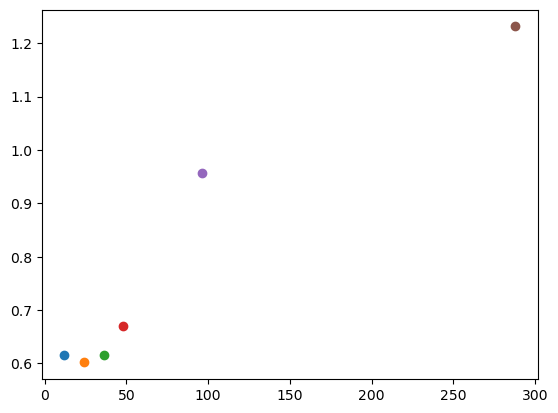

In [37]:
""" 
Do the same but s_45
"""

#Save path
spath="/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/"
#spath = "/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/hyak_output/BCs_s45/outputs/"

#params
folders = ["BC_10"] #Boundary Conditions (for different peak frequencies
cur_files = ["100_12", "100_24", "100_36", "100_48", "100_96","100_288", "100_steady_west"] #Current Widths
#cur_files = ["100_12", "100_24","100_36"]#, "100_steady_west"] #Current Widths

#dirs = ["west", "north", "east", "south"] #Different physics parameters
#runs_labels = ["advection", "k-shift", "refraction", "total currents"]

#cur_labels=["$c_g/fL$=3", "$c_g/fL$=6", "$c_g/fL$=10", "$c_g/fL$=13", "$c_g/fL$=27", "$c_g/fL$=80", "$c_g/fL$=$\infty$"]
#cur_labels = ['$T_{i}=12hrs$', '$T_{i}=48hrs$', '$T_{i}=288hrs$']
#fig, ax = plt.subplots(len(cur_files)+1, len(dirs), figsize=(20, 15)) # Make figure

ww3_data_control= xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/BC_10/100_288/no_cur.nc")
xkm = np.linspace(-haversine((0, -150), (0, -140), unit=Unit.KILOMETERS)/2, haversine((0, -150), (0, -140), unit=Unit.KILOMETERS)/2, len(ww3_data_control.longitude))
ykm = np.linspace(-haversine((-5, -145), (5, -145), unit=Unit.KILOMETERS)/2, haversine((-5, -145), (5, -140), unit=Unit.KILOMETERS)/2, len(ww3_data_control.latitude))

#fig, ax = plt.subplots(4, 4, figsize=(25, 8))
plt.figure()
#fake_cbar = ax[0,0].contourf(xkm, ykm, test.reshape((len(xkm), len(ykm))), vmin=-6, vmax=6, levels=20, cmap='bwr')
bc = "BC_10"
for i in range(len(cur_files)):
    cur = cur_files[i]

    data = xr.open_dataset(spath+bc+"/"+cur+"/all_cur.nc")
    control = xr.open_dataset(spath+bc+"/"+"100_288"+"/"+"no_cur"+".nc")
    indsw =  find_phase_inds(data, 'west', 0.2)
    anom = 100*(data.hs - control.hs)/control.hs
   
    if cur!="100_steady_west":
        Ti = float(cur.split('_')[1])
        dhsdy = np.gradient(anom[indsw[-1], :, :], ykm, axis=0)
        dhsdx = np.gradient(anom[indsw[-1], :, :], xkm, axis=1)
        top = np.nanmean(dhsdy[2:-2, 2:-2]**2)
        bot = np.nanmean(dhsdx[2:-2, 2:-2]**2)
        ratio = np.sqrt(top/bot)
    else:
        dhsdy = np.gradient(anom[2000, :, :], ykm, axis=0)
        dhsdx = np.gradient(anom[2000, :, :], xkm, axis=1)
        top = np.nanmean(dhsdy[2:-2, 2:-2]**2)
        bot = np.nanmean(dhsdx[2:-2, 2:-2]**2)
        ratio = np.sqrt(top/bot)
        Ti = 500
    plt.scatter(Ti, ratio)


plt.title("$\lambda_x/\lambda_y$")
#plt.savefig("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/figures/comparing_fs"+str(sigma)+".png", dpi = 300, bbox_inches='tight')



In [211]:
dhsdy = np.gradient(hs_anomaly[indsw[-1], :, :], ykm, axis=0)
dhsdx = np.gradient(hs_anomaly[indsw[-1], :, :], xkm, axis=1)
top = np.nanmean(dhsdy**2)
bot = np.nanmean(dhsdx**2)
ratio24 = np.sqrt(top/bot)

spath="/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/outputs/BC_10/"
data_steady = xr.open_dataset(spath+"/100_steady_west/all_cur.nc")
anom_steady = 100*(data_steady.hs - control.hs)/control.hs
dhsdy_steady = np.gradient(anom_steady[700:, :, :], ykm, axis=1)
dhsdx_steady = np.gradient(anom_steady[700:, :, :], xkm, axis=2)
top = np.nanmean(dhsdy_steady**2)
bot = np.nanmean(dhsdx_steady**2)
ratio_steady = np.sqrt(top/bot)
print(ratio_steady, ratio24)

1.2613634 0.593706


# Plot spectra at West 1 and East 1 for different phases

In [247]:

cur24 = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/equator_currents/right_rotating/equator_currents_100_steady_west.nc")
#cur12 = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/equator_currents/right_rotating/equator_currents_100_12.nc")

alpha24 = (cur24.u_div**2 + cur24.v_div**2)/ (cur24.ucur**2 + cur24.vcur**2)






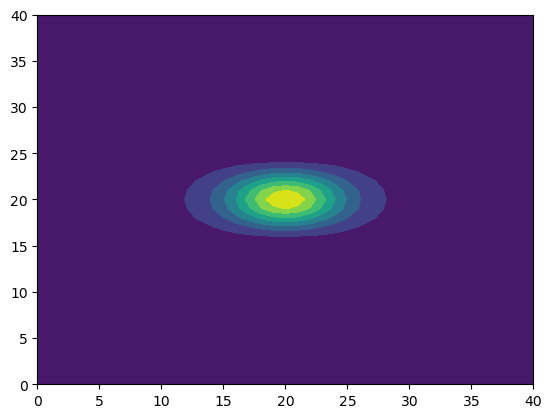

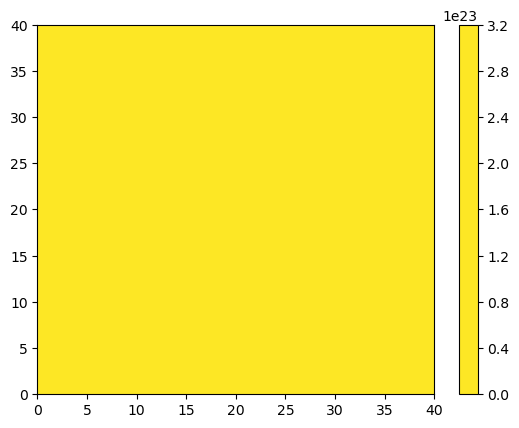

In [248]:
plt.contourf((cur24.u_rot**2)[10, :, :])
plt.figure()
plt.contourf(alpha24[10, :, :], vmin=0, vmax=100)
plt.colorbar()

In [250]:
np.nanmin(cur24.vcur[10, :, :])**2+np.nanmin(cur24.ucur[10, :, :])**2

0.04000000000000001

In [255]:
np.nanmin(cur24.v_div[10, :, :])**2+np.nanmin(cur24.u_div[10, :, :])**2

0.009137237506832657

In [256]:
0.009137237506832657/0.012675331823509035


0.7208677164479239

In [242]:
np.nanmin(cur24.u_div**2 + cur24.v_div**2)

2.0176853528049183e-10

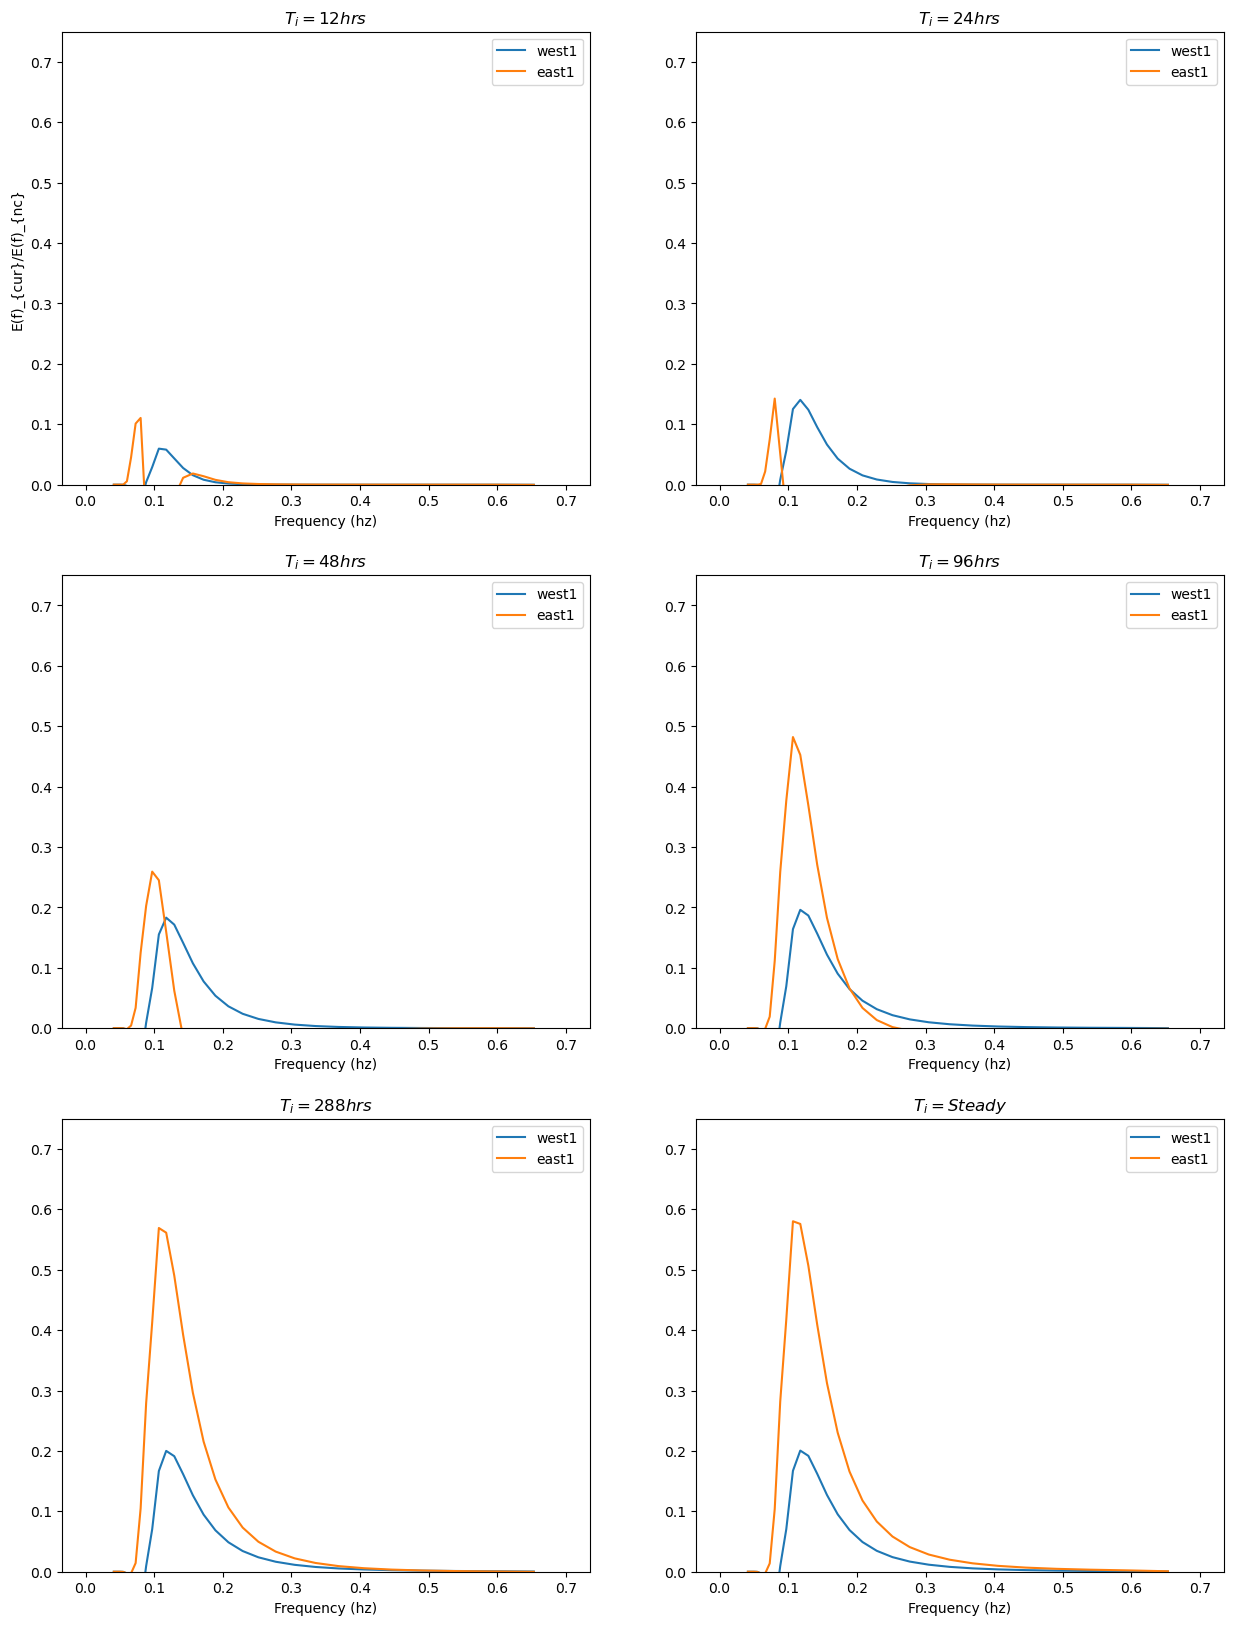

In [166]:
#Save path
spath = "/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/hyak_output/BCs_s45/outputs/"
#params
folders = ["BC_10"] #Boundary Conditions (for different peak frequencies
#cur_files = ["100_12", "100_24", "100_36", "100_48", "100_96","100_288", "100_steady_west"] #Current Widths
cur_files = ["100_12","100_24","100_48","100_96", "100_288", "100_steady_west"]#, "100_steady_west"] #Current Widths

dirs = ["west", "north", "east", "south"] #Different physics parameters
#runs_labels = ["advection", "k-shift", "refraction", "total currents"]

#cur_labels=["$c_g/fL$=3", "$c_g/fL$=6", "$c_g/fL$=10", "$c_g/fL$=13", "$c_g/fL$=27", "$c_g/fL$=80", "$c_g/fL$=$\infty$"]
cur_labels = ['$T_{i}=12hrs$', '$T_{i}=24hrs$', '$T_{i}=48hrs$', '$T_{i}=96hrs$', '$T_{i}=288hrs$', '$T_{i}=Steady$',]

#Load a sample spec from BC files to normalize by:
control_spec = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/BCs_s45/BC_10/boundary_spec_bottom_0.nc")
control_spec = control_spec.sortby('direction')
control_spec['direction'] = np.pi*control_spec['direction']/180
control_spec = control_spec.integrate('direction')

fig, ax = plt.subplots(3, 2, figsize=(15, 20))
ax = ax.flatten()
#fake_cbar = ax[0,0].contourf(xkm, ykm, test.reshape((len(xkm), len(ykm))), vmin=-6, vmax=6, levels=20, cmap='bwr')
bc = "BC_10"
for i in range(len(cur_files)):
    cur = cur_files[i]
    #Plot different currents as rows and phsyics runs as columns
    row_count = i
    col_count = 0
    #data = xr.open_dataset(spath+bc+"/"+cur+"/all_cur.nc")
    west1 = xr.open_dataset(spath+bc+"/"+cur+"/specs/all_cur_full/ww3.West1_2019_spec.nc")
    east1 = xr.open_dataset(spath+bc+"/"+cur+"/specs/all_cur_full/ww3.East1_2019_spec.nc")
    west1 = west1.sortby('direction')
    east1 = east1.sortby('direction')
    west1['direction'] = np.pi*west1['direction']/180
    east1['direction'] = np.pi*east1['direction']/180
    west1 = west1.integrate('direction')
    east1 = east1.integrate('direction')

    data = xr.open_dataset(spath+bc+"/"+cur+"/all_cur_full.nc") #Need to load full data to get the velocities for indicies
    #data time is every 10min but spec time is hourly
    data = data.interp(time =west1.time, method='linear')
    
    #Get cur name
    cur = cur_files[i]
    #for run_i in range(len(dirs)):
    inds = find_phase_inds(data, 'west', 0.2)
    ax[i].plot(west1.frequency, west1.efth[inds[-1], 0, :].values-control_spec.efth[0, 0, :].values, color='tab:blue', label='west1')
    ax[i].plot(east1.frequency, east1.efth[inds[-1], 0, :].values-control_spec.efth[0, 0, :].values, color='tab:orange', label='east1')


    ax[i].legend()
    ax[i].set_ylim(0, 0.75)
    ax[i].set_title(cur_labels[i])
    ax[i].set_xlabel("Frequency (hz)")
    ax[0].set_ylabel("E(f)_{cur}/E(f)_{nc}")
    ax[i].hlines(y=1.00, xmin=0, xmax=0.7, color='k', linestyles='--')
#plt.savefig("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/figures/comparing_fs"+str(sigma)+".png", dpi = 300, bbox_inches='tight')



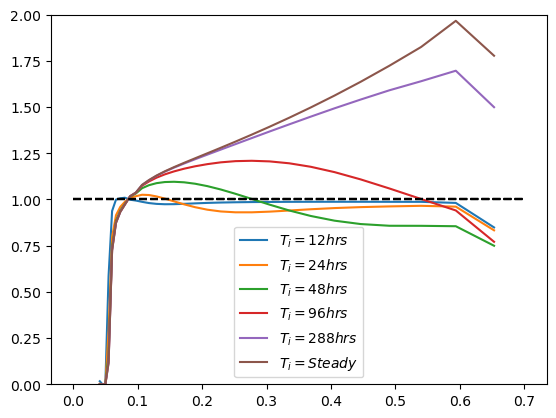

In [69]:
#Save path
spath = "/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/hyak_output/BCs_s45/outputs/"
#params
folders = ["BC_10"] #Boundary Conditions (for different peak frequencies
#cur_files = ["100_12", "100_24", "100_36", "100_48", "100_96","100_288", "100_steady_west"] #Current Widths
cur_files = ["100_12","100_24","100_48","100_96", "100_288", "100_steady_west"]#, "100_steady_west"] #Current Widths

dirs = ["west", "north", "east", "south"] #Different physics parameters
#runs_labels = ["advection", "k-shift", "refraction", "total currents"]

#cur_labels=["$c_g/fL$=3", "$c_g/fL$=6", "$c_g/fL$=10", "$c_g/fL$=13", "$c_g/fL$=27", "$c_g/fL$=80", "$c_g/fL$=$\infty$"]
cur_labels = ['$T_{i}=12hrs$', '$T_{i}=24hrs$', '$T_{i}=48hrs$', '$T_{i}=96hrs$', '$T_{i}=288hrs$', '$T_{i}=Steady$',]

#Load a sample spec from BC files to normalize by:
control_spec = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/BCs_s45/BC_10/boundary_spec_bottom_0.nc")
control_spec = control_spec.sortby('direction')
control_spec['direction'] = np.pi*control_spec['direction']/180
control_spec = control_spec.integrate('direction')

#fig, ax = plt.subplots(3, 2, figsize=(15, 20))
fig, ax = plt.subplots(1,1)
bc = "BC_10"
for i in range(len(cur_files)):
    cur = cur_files[i]
    #Plot different currents as rows and phsyics runs as columns
    row_count = i
    col_count = 0
    #data = xr.open_dataset(spath+bc+"/"+cur+"/all_cur.nc")
    center = xr.open_dataset(spath+bc+"/"+cur+"/specs/all_cur_full/ww3.Center_2019_spec.nc")
    center = center.sortby('direction')
    center['direction'] = np.pi*center['direction']/180
    center = center.integrate('direction')

    data = xr.open_dataset(spath+bc+"/"+cur+"/all_cur_full.nc") #Need to load full data to get the velocities for indicies
    #data time is every 10min but spec time is hourly
    data = data.interp(time =center.time, method='linear')
    
    #Get cur name
    cur = cur_files[i]
    #for run_i in range(len(dirs)):
    inds = find_phase_inds(data, 'west', 0.2)
    ax.plot(center.frequency, center.efth[inds[-1], 0, :].values/control_spec.efth[0, 0, :].values, label=cur_labels[i])


    ax.legend()
    ax.set_ylim(0, 2)
    ax.set_title
    ax.hlines(y=1.00, xmin=0, xmax=0.7, color='k', linestyles='--')
#plt.savefig("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/figures/comparing_fs"+str(sigma)+".png", dpi = 300, bbox_inches='tight')



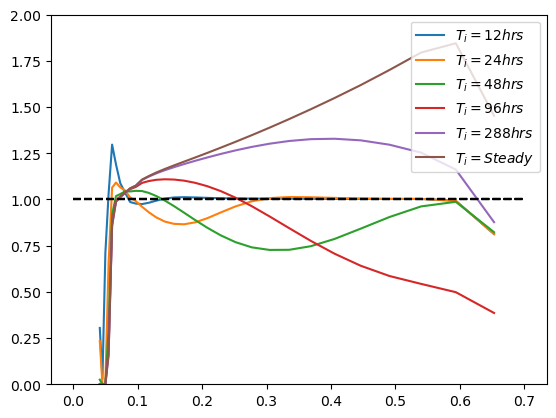

In [78]:
#Save path
spath = "/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/hyak_output/BCs_s45/outputs/"
#params
folders = ["BC_10"] #Boundary Conditions (for different peak frequencies
#cur_files = ["100_12", "100_24", "100_36", "100_48", "100_96","100_288", "100_steady_west"] #Current Widths
cur_files = ["100_12","100_24","100_48","100_96", "100_288", "100_steady_west"]#, "100_steady_west"] #Current Widths

dirs = ["west", "north", "east", "south"] #Different physics parameters
#runs_labels = ["advection", "k-shift", "refraction", "total currents"]

#cur_labels=["$c_g/fL$=3", "$c_g/fL$=6", "$c_g/fL$=10", "$c_g/fL$=13", "$c_g/fL$=27", "$c_g/fL$=80", "$c_g/fL$=$\infty$"]
cur_labels = ['$T_{i}=12hrs$', '$T_{i}=24hrs$', '$T_{i}=48hrs$', '$T_{i}=96hrs$', '$T_{i}=288hrs$', '$T_{i}=Steady$',]

#Load a sample spec from BC files to normalize by:
control_spec = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/BCs_s45/BC_10/boundary_spec_bottom_0.nc")
control_spec = control_spec.sortby('direction')
control_spec['direction'] = np.pi*control_spec['direction']/180
control_spec = control_spec.integrate('direction')

#fig, ax = plt.subplots(3, 2, figsize=(15, 20))
fig, ax = plt.subplots(1,1)
bc = "BC_10"
for i in range(len(cur_files)):
    cur = cur_files[i]
    #Plot different currents as rows and phsyics runs as columns
    row_count = i
    col_count = 0
    #data = xr.open_dataset(spath+bc+"/"+cur+"/all_cur.nc")
    center = xr.open_dataset(spath+bc+"/"+cur+"/specs/all_cur_full/ww3.East1_2019_spec.nc")
    center = center.sortby('direction')
    center['direction'] = np.pi*center['direction']/180
    center = center.integrate('direction')

    data = xr.open_dataset(spath+bc+"/"+cur+"/all_cur_full.nc") #Need to load full data to get the velocities for indicies
    #data time is every 10min but spec time is hourly
    data = data.interp(time =center.time, method='linear')
    
    #Get cur name
    cur = cur_files[i]
    #for run_i in range(len(dirs)):
    inds = find_phase_inds(data, 'west', 0.2)
    ax.plot(center.frequency, center.efth[inds[-1], 0, :].values/control_spec.efth[0, 0, :].values, label=cur_labels[i])


    ax.legend()
    ax.set_ylim(0, 2)
    ax.set_title
    ax.hlines(y=1.00, xmin=0, xmax=0.7, color='k', linestyles='--')
#plt.savefig("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/figures/comparing_fs"+str(sigma)+".png", dpi = 300, bbox_inches='tight')



In [70]:
cgs = (9.8/(4*np.pi))*(1/center.frequency)


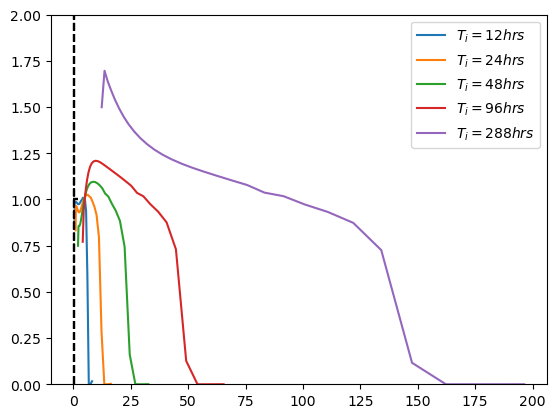

In [81]:
#Save path
spath = "/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/hyak_output/BCs_s45/outputs/"
#params
folders = ["BC_10"] #Boundary Conditions (for different peak frequencies
#cur_files = ["100_12", "100_24", "100_36", "100_48", "100_96","100_288", "100_steady_west"] #Current Widths
cur_files = ["100_12","100_24","100_48","100_96", "100_288"]#, "100_steady_west"]#, "100_steady_west"] #Current Widths

dirs = ["west", "north", "east", "south"] #Different physics parameters
#runs_labels = ["advection", "k-shift", "refraction", "total currents"]

#cur_labels=["$c_g/fL$=3", "$c_g/fL$=6", "$c_g/fL$=10", "$c_g/fL$=13", "$c_g/fL$=27", "$c_g/fL$=80", "$c_g/fL$=$\infty$"]
cur_labels = ['$T_{i}=12hrs$', '$T_{i}=24hrs$', '$T_{i}=48hrs$', '$T_{i}=96hrs$', '$T_{i}=288hrs$', '$T_{i}=Steady$',]

#Load a sample spec from BC files to normalize by:
control_spec = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/BCs_s45/BC_10/boundary_spec_bottom_0.nc")
control_spec = control_spec.sortby('direction')
control_spec['direction'] = np.pi*control_spec['direction']/180
control_spec = control_spec.integrate('direction')

#fig, ax = plt.subplots(3, 2, figsize=(15, 20))
fig, ax = plt.subplots(1,1)
bc = "BC_10"
for i in range(len(cur_files)):
    cur = cur_files[i]
    #Plot different currents as rows and phsyics runs as columns
    row_count = i
    col_count = 0
    #data = xr.open_dataset(spath+bc+"/"+cur+"/all_cur.nc")
    center = xr.open_dataset(spath+bc+"/"+cur+"/specs/all_cur_full/ww3.Center_2019_spec.nc")
    center = center.sortby('direction')
    center['direction'] = np.pi*center['direction']/180
    center = center.integrate('direction')
    T_i = float(cur.split('_')[1])
    cgtls = cgs*60*60*T_i/(100000)
    cgus = cgs/0.2
    data = xr.open_dataset(spath+bc+"/"+cur+"/all_cur_full.nc") #Need to load full data to get the velocities for indicies
    #data time is every 10min but spec time is hourly
    data = data.interp(time =center.time, method='linear')
    
    #Get cur name
    cur = cur_files[i]
    #for run_i in range(len(dirs)):
    inds = find_phase_inds(data, 'west', 0.2)
    ax.plot(cgtls, center.efth[inds[-1], 0, :].values/control_spec.efth[0, 0, :].values, label=cur_labels[i])


    ax.legend()
    ax.set_ylim(0, 2)
    #ax.set_titl
    #ax.set_xlim(0, 15)
    ax.hlines(y=1.00, xmin=0, xmax=2, color='k', linestyles='--')
    ax.vlines(x=0.2, ymin=0, ymax=2, color='k', linestyles='--')
#plt.savefig("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/figures/comparing_fs"+str(sigma)+".png", dpi = 300, bbox_inches='tight')

